**Exploratory Analysis**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('spotify_music_cleaned.csv')

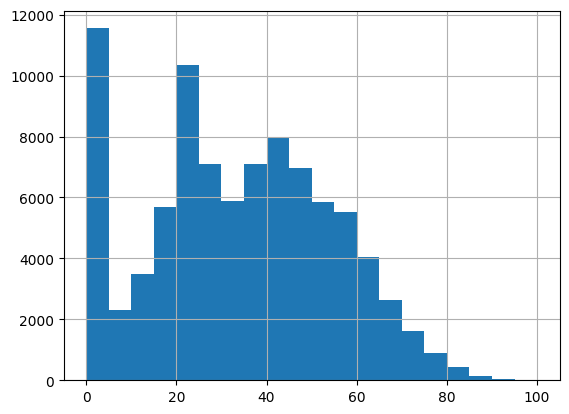

In [2]:
#visualizing the distribution of popularity scores across songs
df["popularity"].hist(bins = 20)
plt.show()

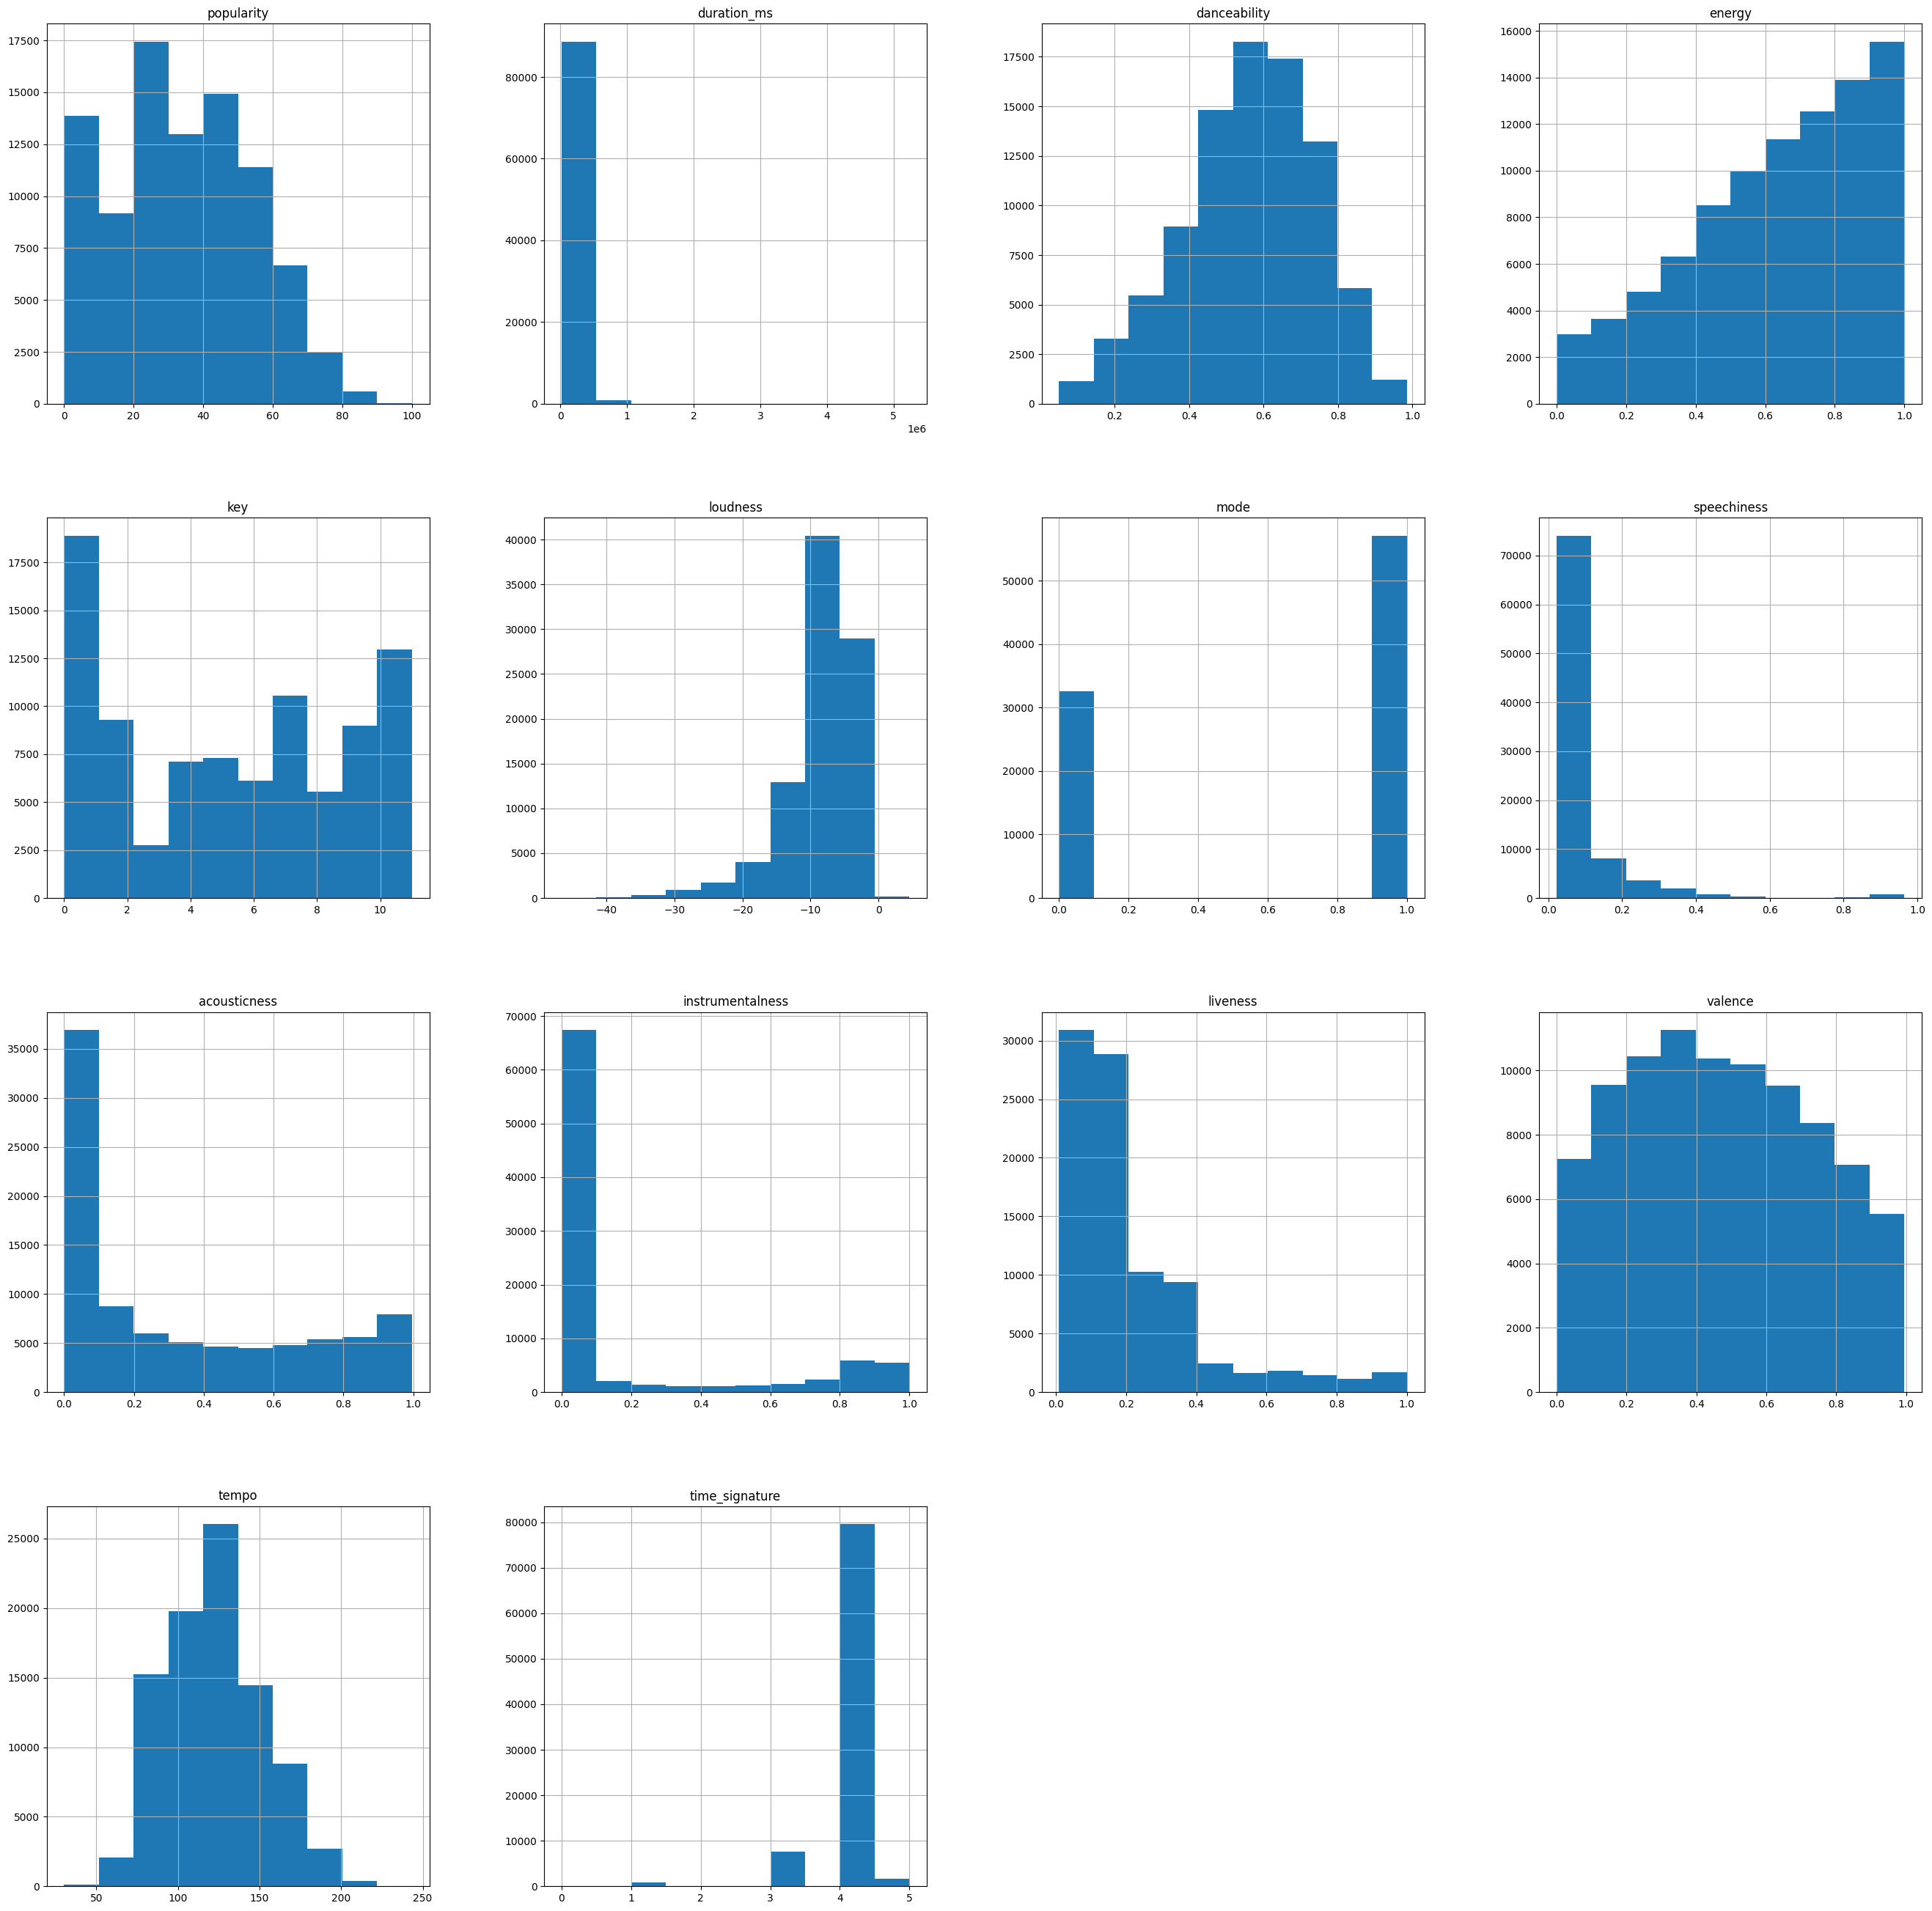

In [3]:
#visualizing distribution of different columns (tempo, key, acousticness, etc)
#showing how many songs fall into each category of the different columns
df.hist(figsize=(33, 33))
plt.show()

**Histogram column observations**

- seems to be a lot more songs with a higher energy (skewed left)
- most songs have a low acousticness level (0 - 0.1) is where most of the data lies
- almost all songs have the same time signature of 4/4
- not a lot of songs seem to have a high level of liveness, most of the data is in (0 - 0.2)
- Valence levels across songs are pretty much equally distributed
- Tempo has a bell curve shape and tends to be around 100-150 bpm for most songs
- Majority of songs have a low level of instrumentalness and speechiness
- Most songs sit between -10 to 0 decibels
- key is pretty various, no clear pattern



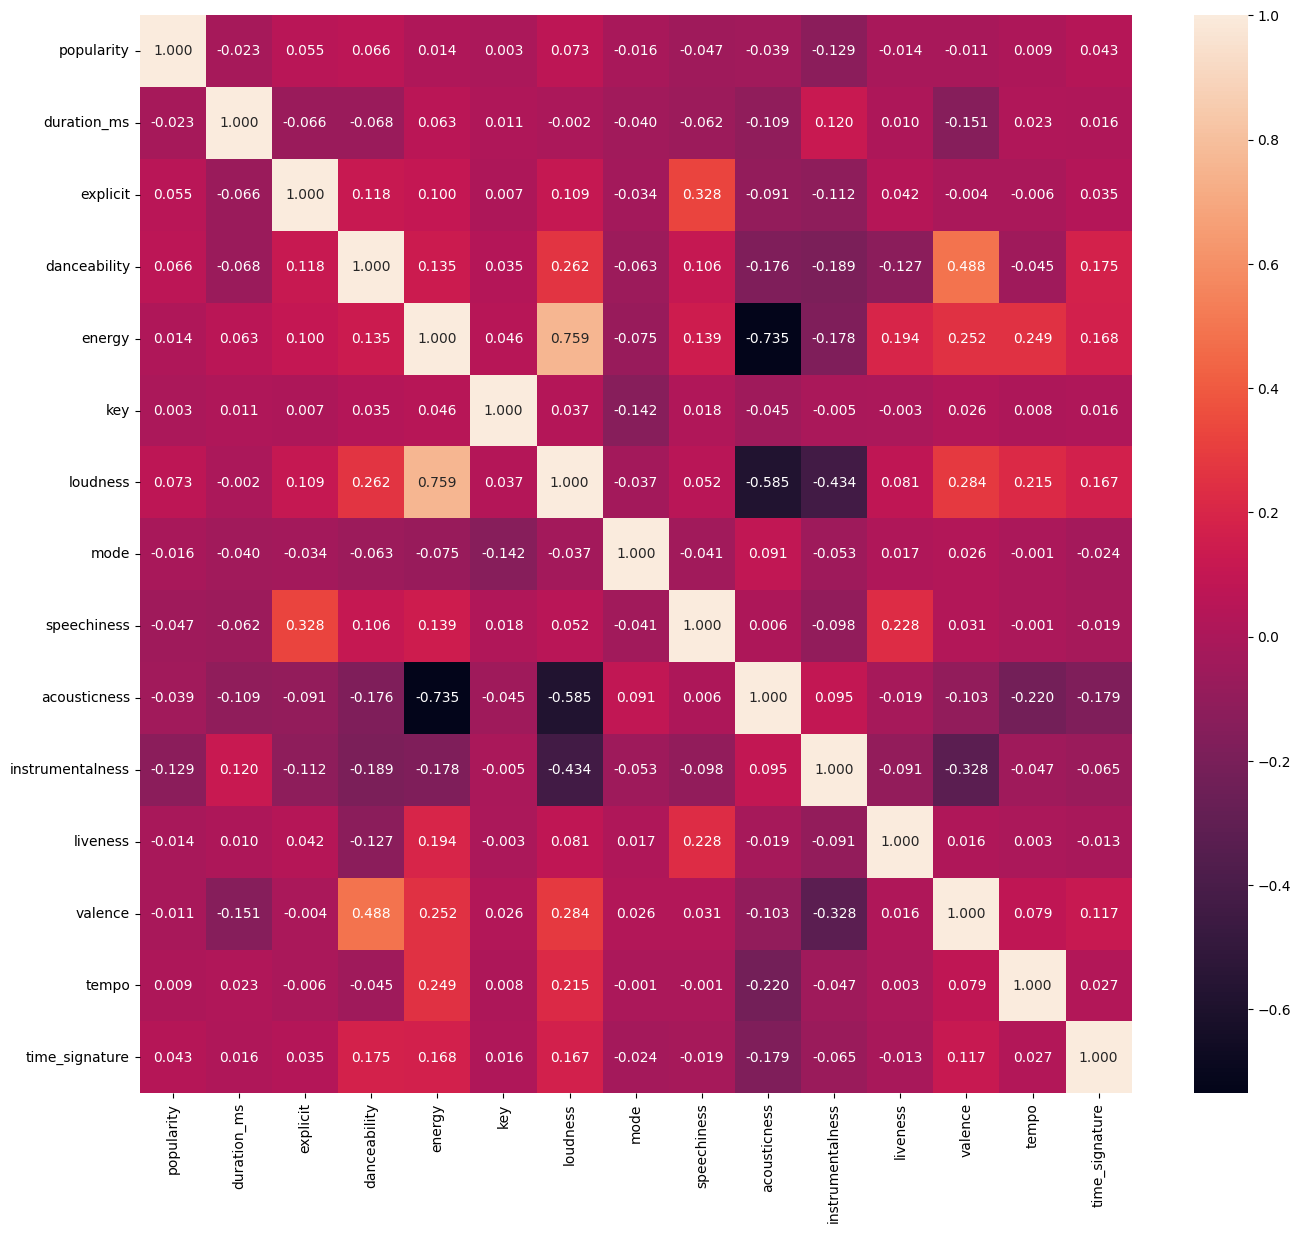

In [4]:
correlation_table = df.corr(numeric_only=True)
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_table, annot=True, annot_kws = {"size": 10},fmt = ".3f")

plt.show()




In [5]:
#printing out highest correlation values. using head and tail to get the 5 most positive correlations and 5 most negative
popularity_correlation = correlation_table['popularity'].sort_values(ascending=False)
print(popularity_correlation.tail())
print(popularity_correlation.head())

mode               -0.016241
duration_ms        -0.023107
acousticness       -0.038991
speechiness        -0.046861
instrumentalness   -0.128516
Name: popularity, dtype: float64
popularity        1.000000
loudness          0.073262
danceability      0.065965
explicit          0.055022
time_signature    0.042696
Name: popularity, dtype: float64


**Heatmap Visualization Observations**
- There is a high negative correlation between acousticness and energy
- There is a high negative correlation between acousticness and loudness
- Based on looking at correlation between poularity values and different variables, there was no clear **linear** correlation.
- The strongest correlation when comparing variables to popularity was **-0.129** and that was between instrumentalness and popularity.

Conclusion: popularity is likely not determined by a linear relationship with these song variables.


13


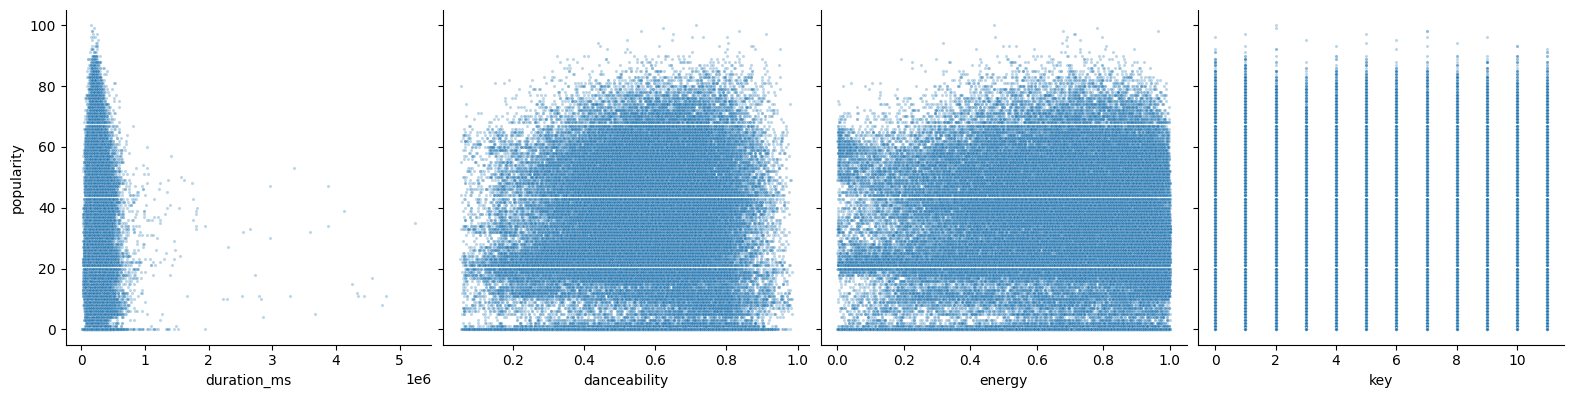

In [6]:
feature_cols = df.select_dtypes(include='number').columns.drop('popularity')
print(len(feature_cols))
sns.pairplot(data=df, x_vars=feature_cols[:4], y_vars=['popularity'], height=4, plot_kws={'alpha':0.3, 's':5})


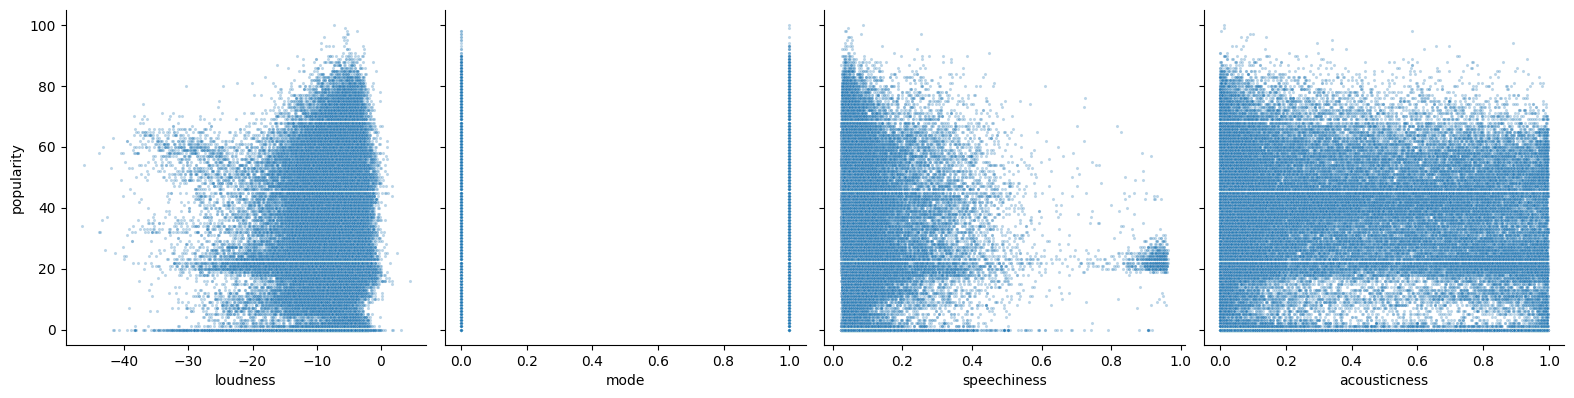

In [7]:
sns.pairplot(data=df, x_vars=feature_cols[4:8], y_vars=['popularity'], height=4, plot_kws={'alpha':0.3, 's':5})

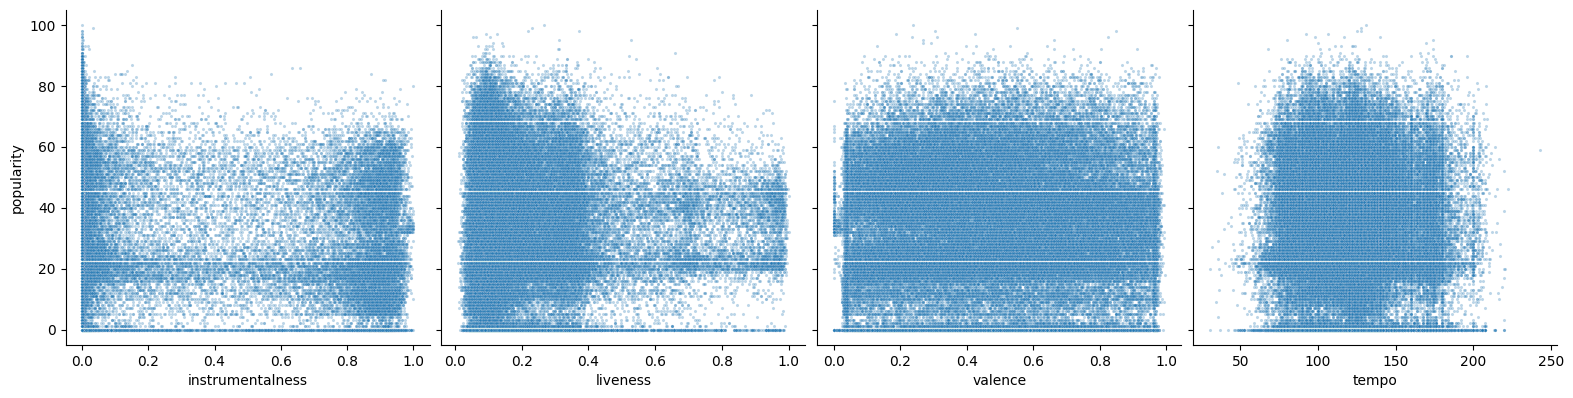

In [8]:
sns.pairplot(data=df, x_vars=feature_cols[8:12], y_vars=['popularity'], height=4, plot_kws={'alpha':0.3, 's':5})

**Scatterplot Visualization Observations**
- can't really notice any clear trends to be honest


**Genre Analysis** (note: no column for song release dates so cant analyze by time period)

In [9]:
genre_groups = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
print(genre_groups.head(10))
print(genre_groups.tail(10))
print(len(genre_groups))

track_genre
k-pop       59.423581
pop-film    59.096933
metal       56.422414
chill       53.738683
latino      51.788945
sad         51.109929
grunge      50.587007
indian      49.765348
anime       48.776884
emo         48.500000
Name: popularity, dtype: float64
track_genre
idm               15.522222
kids              14.770791
grindcore         14.521827
classical         13.362168
chicago-house     12.333667
detroit-techno    11.130753
latin              9.855072
jazz               9.690249
romance            3.524917
iranian            2.233740
Name: popularity, dtype: float64
113


Text(0.5, 1.0, 'Barplot Popularity Distributions of Top 10 and Bottom 10 genres')

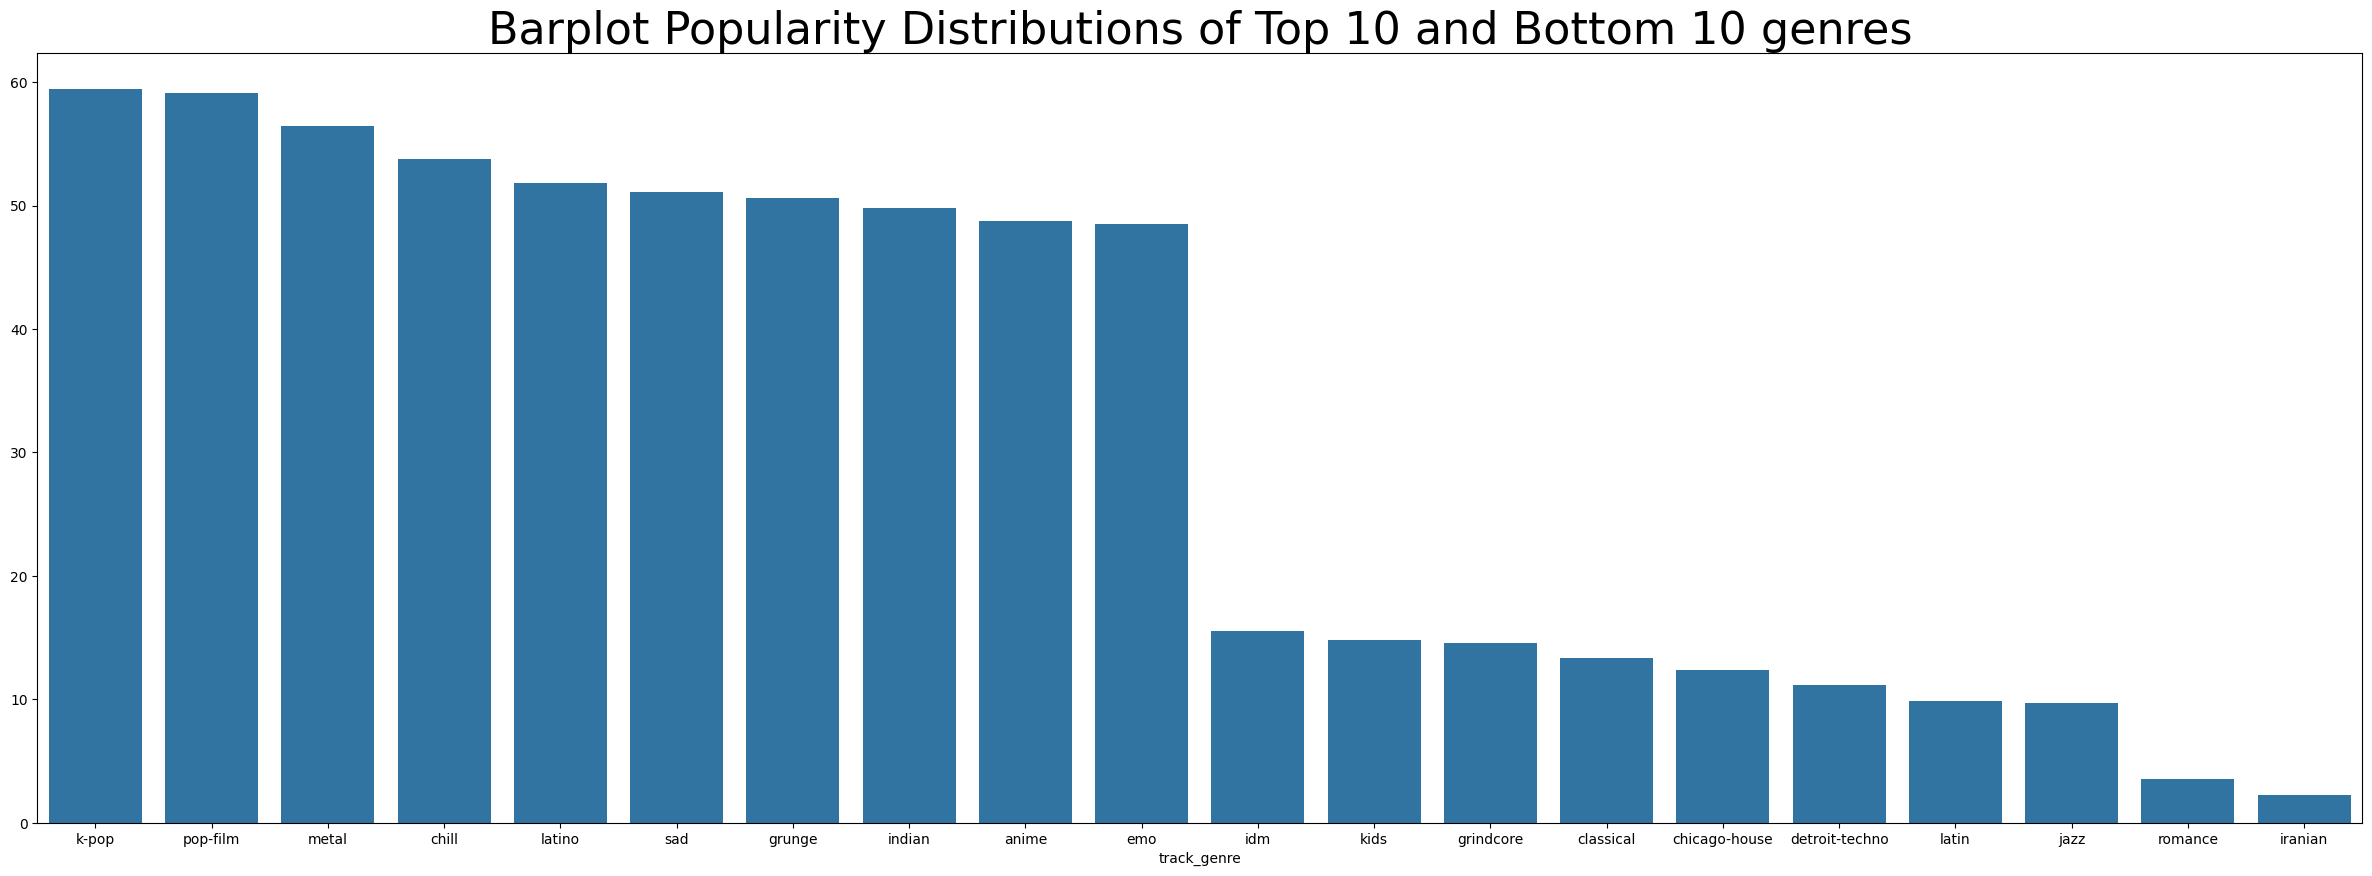

In [10]:
top_bottom_genres = pd.concat([genre_groups.head(10), genre_groups.tail(10)])

plt.figure(figsize=(30, 10))
sns.barplot(x = top_bottom_genres.index, y = top_bottom_genres.values)
plt.title("Barplot Popularity Distributions of Top 10 and Bottom 10 genres", fontsize=32)